# Healthcare Dataset — Billing, Insurance, Revenue & Hospital Analysis

**Dataset:** `engineered_healthcare_dataset.csv` (output of `feature_engineering.ipynb`, 55,500 records)

This notebook covers:
1. Data Loading
2. Billing Analysis
3. Insurance Analysis
4. Revenue Analysis
5. Hospital Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

df = pd.read_csv("engineered_healthcare_dataset.csv")
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])
print(df.shape)
df.head()

(54966, 27)


,Name,Age,Age_Group,Gender,Blood Type,Medical Condition,Date of Admission,Admission_Year,Admission_Month,Admission_DayOfWeek,Admission_Season,Is_Weekend_Admission,Discharge Date,Length_of_Stay,LOS_Category,Discharge_Delay_Flag,Doctor,Doctor_Patient_Count,Hospital,Hospital_Patient_Count,Insurance Provider,Billing Amount,Billing_Per_Day,Room Number,Admission Type,Medication,Test Results
0,Bobby Jackson,30,18-35,Male,B-,Cancer,2024-01-31,2024,1,Wednesday,Winter,False,2024-02-02,2,Short (1-3 days),False,Matthew Smith,17,Sons and Miller,7,Blue Cross,18856.281306,9428.14,328,Urgent,Paracetamol,Normal
1,Leslie Terry,62,51-65,Male,A+,Obesity,2019-08-20,2019,8,Tuesday,Summer,False,2019-08-26,6,Medium (4-10 days),False,Samantha Davies,1,Kim Inc,6,Medicare,33643.327287,5607.22,265,Emergency,Ibuprofen,Inconclusive
2,Danny Smith,76,66+,Female,A-,Obesity,2022-09-22,2022,9,Thursday,Fall,False,2022-10-07,15,Long (11-20 days),False,Tiffany Mitchell,1,Cook PLC,4,Aetna,27955.096079,1863.67,205,Emergency,Aspirin,Normal
3,Andrew Watts,28,18-35,Female,O+,Diabetes,2020-11-18,2020,11,Wednesday,Fall,False,2020-12-18,30,Extended (21+ days),True,Kevin Wells,1,"Hernandez Rogers and Vang,",1,Medicare,37909.782410,1263.66,450,Elective,Ibuprofen,Abnormal
4,Adrienne Bell,43,36-50,Female,AB+,Cancer,2022-09-19,2022,9,Monday,Fall,False,2022-10-09,20,Long (11-20 days),False,Kathleen Hanna,2,White-White,2,Aetna,14238.317814,711.92,458,Urgent,Penicillin,Abnormal


## 1. Data Loading

Loads the cleaned, feature-engineered dataset produced by `feature_engineering.ipynb` — deduplicated, with `Length_of_Stay`, `Age_Group`, `Billing_Per_Day`, and other derived fields already attached.

In [2]:
df[["Billing Amount", "Billing_Per_Day", "Length_of_Stay"]].describe().round(2)

,Billing Amount,Billing_Per_Day,Length_of_Stay
count,54966.00,54966.00,54966.00
mean,25546.24,3392.69,15.50
std,14204.92,5797.69,8.66
min,9.24,0.80,1.00
25%,13243.72,856.24,8.00
50%,25542.75,1649.59,15.00
75%,37819.86,3205.44,23.00
max,52764.28,52211.85,30.00


## 2. Billing Analysis

Distribution of total billing amounts, by medical condition, admission type, and outlier detection (IQR method).

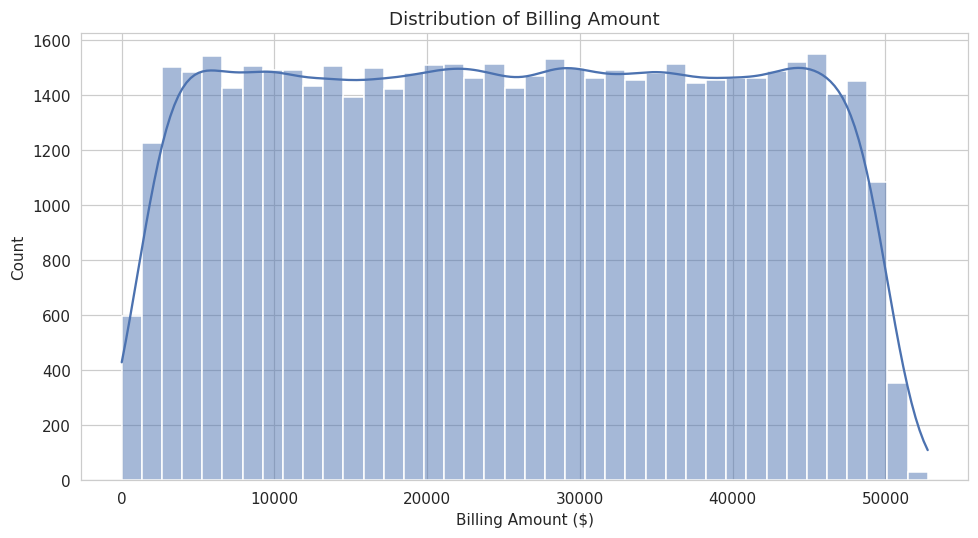

count    54966.00
mean     25546.24
std      14204.92
min          9.24
25%      13243.72
50%      25542.75
75%      37819.86
max      52764.28
Name: Billing Amount, dtype: float64

In [3]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Billing Amount"], bins=40, kde=True, color="#4C72B0")
plt.title("Distribution of Billing Amount")
plt.xlabel("Billing Amount ($)")
plt.tight_layout()
plt.show()

df["Billing Amount"].describe().round(2)

Q1=13243.72, Q3=37819.86, IQR=24576.14
Bounds: [-23620.49, 74684.07]
Outlier billing records: 0 (0.00%)


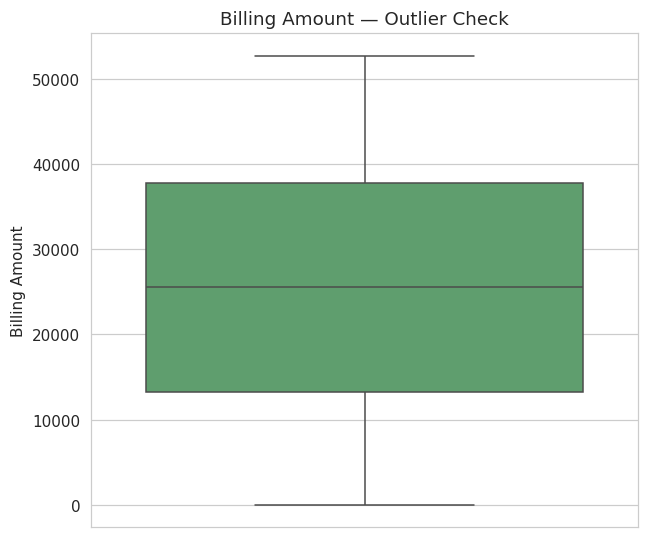

In [4]:
Q1, Q3 = df["Billing Amount"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
billing_outliers = ((df["Billing Amount"] < lower) | (df["Billing Amount"] > upper)).sum()

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Outlier billing records: {billing_outliers} ({billing_outliers/len(df)*100:.2f}%)")

plt.figure(figsize=(6, 5))
sns.boxplot(y=df["Billing Amount"], color="#55A868")
plt.title("Billing Amount — Outlier Check")
plt.tight_layout()
plt.show()

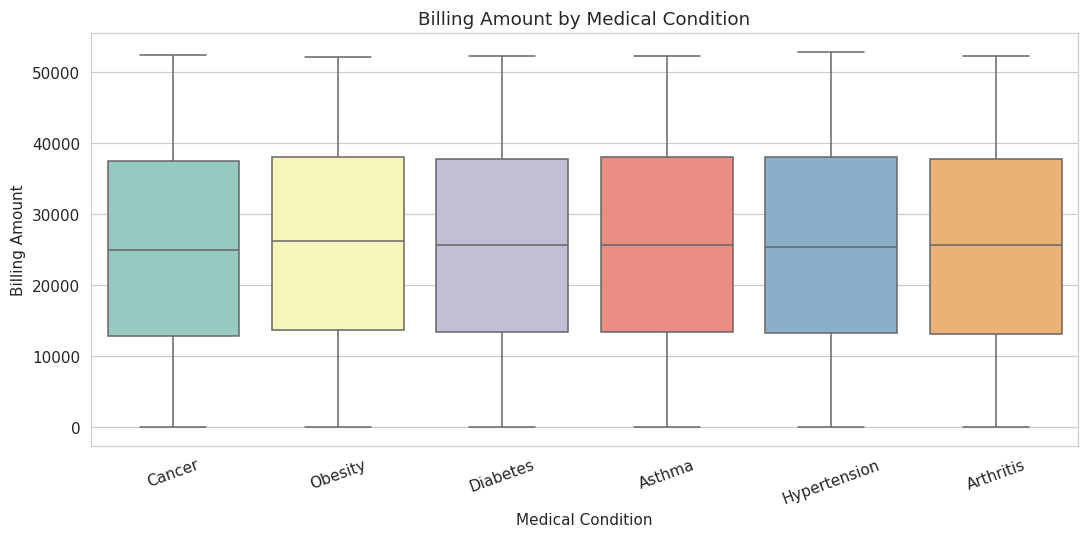

Medical Condition
Obesity         25806.63
Diabetes        25662.15
Asthma          25635.64
Arthritis       25513.05
Hypertension    25504.91
Cancer          25154.73
Name: Billing Amount, dtype: float64

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Medical Condition", y="Billing Amount", hue="Medical Condition", legend=False, palette="Set3")
plt.title("Billing Amount by Medical Condition")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

df.groupby("Medical Condition")["Billing Amount"].mean().round(2).sort_values(ascending=False)

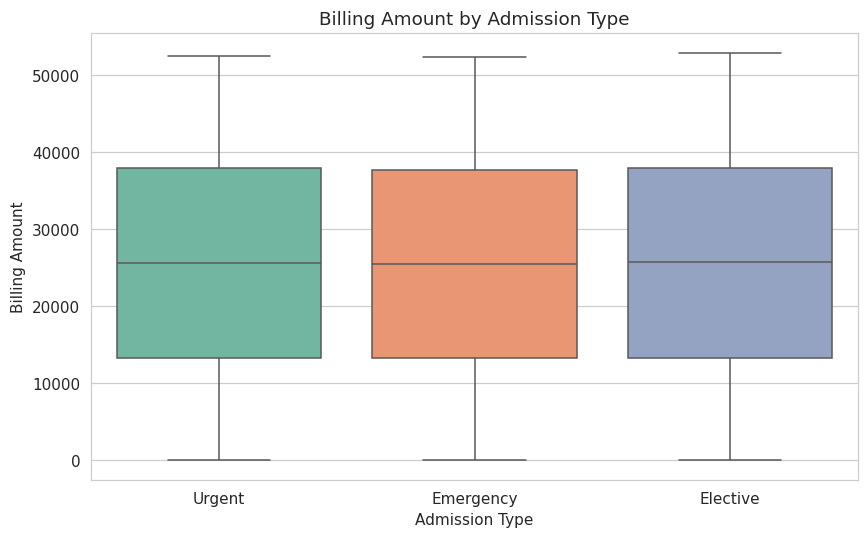

Admission Type
Elective     25614.52
Emergency    25506.60
Urgent       25516.69
Name: Billing Amount, dtype: float64

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Admission Type", y="Billing Amount", hue="Admission Type", legend=False, palette="Set2")
plt.title("Billing Amount by Admission Type")
plt.tight_layout()
plt.show()

df.groupby("Admission Type")["Billing Amount"].mean().round(2)

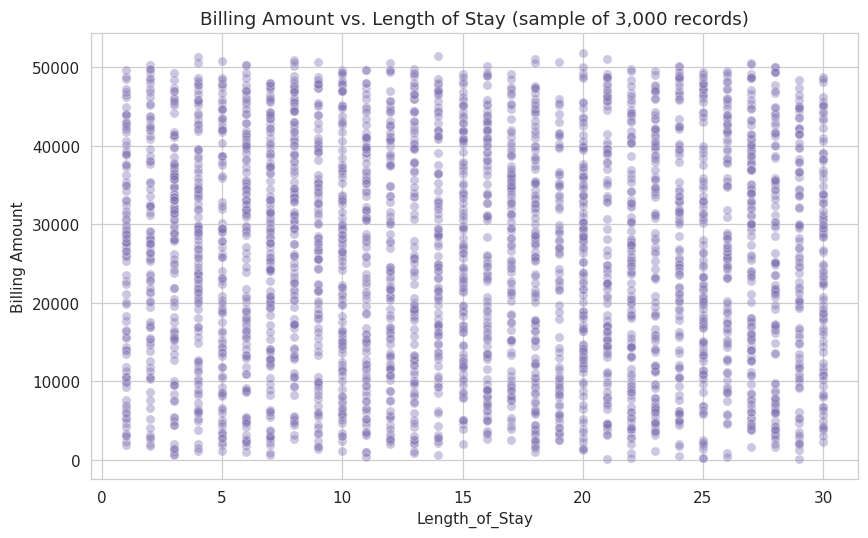

Correlation (Billing Amount, Length of Stay): -0.005


In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(3000, random_state=42), x="Length_of_Stay", y="Billing Amount", alpha=0.4, color="#8172B2")
plt.title("Billing Amount vs. Length of Stay (sample of 3,000 records)")
plt.tight_layout()
plt.show()

print("Correlation (Billing Amount, Length of Stay):", df["Billing Amount"].corr(df["Length_of_Stay"]).round(3))

## 3. Insurance Analysis

Patient volume and average billing broken down by insurance provider.

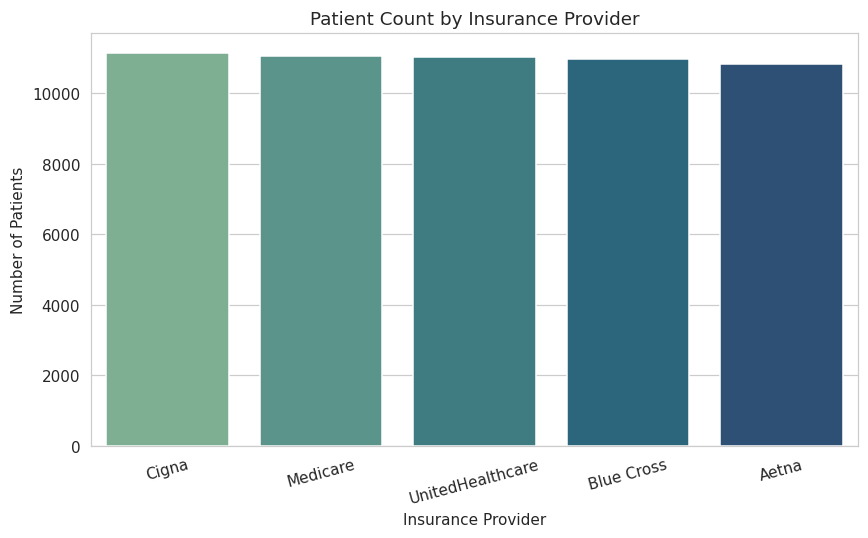

Insurance Provider
Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: count, dtype: int64

In [8]:
insurance_counts = df["Insurance Provider"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=insurance_counts.index, y=insurance_counts.values, hue=insurance_counts.index, legend=False, palette="crest")
plt.title("Patient Count by Insurance Provider")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
insurance_counts

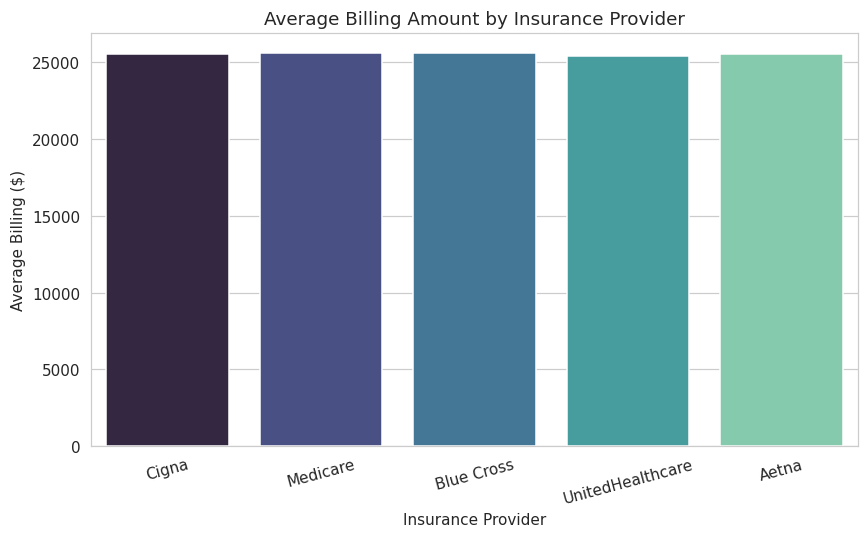

,Avg_Billing,Median_Billing,Total_Billing
Insurance Provider,,,
Cigna,25528.22,25537.18,2.843588e+08
Medicare,25630.16,25629.33,2.829313e+08
Blue Cross,25604.85,25580.54,2.804243e+08
UnitedHealthcare,25415.44,25222.11,2.799257e+08
Aetna,25553.02,25765.38,2.765347e+08


In [9]:
insurance_billing = df.groupby("Insurance Provider")["Billing Amount"].agg(["mean", "median", "sum"]).round(2).sort_values("sum", ascending=False)
insurance_billing.columns = ["Avg_Billing", "Median_Billing", "Total_Billing"]

plt.figure(figsize=(8, 5))
sns.barplot(x=insurance_billing.index, y=insurance_billing["Avg_Billing"], hue=insurance_billing.index, legend=False, palette="mako")
plt.title("Average Billing Amount by Insurance Provider")
plt.ylabel("Average Billing ($)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
insurance_billing

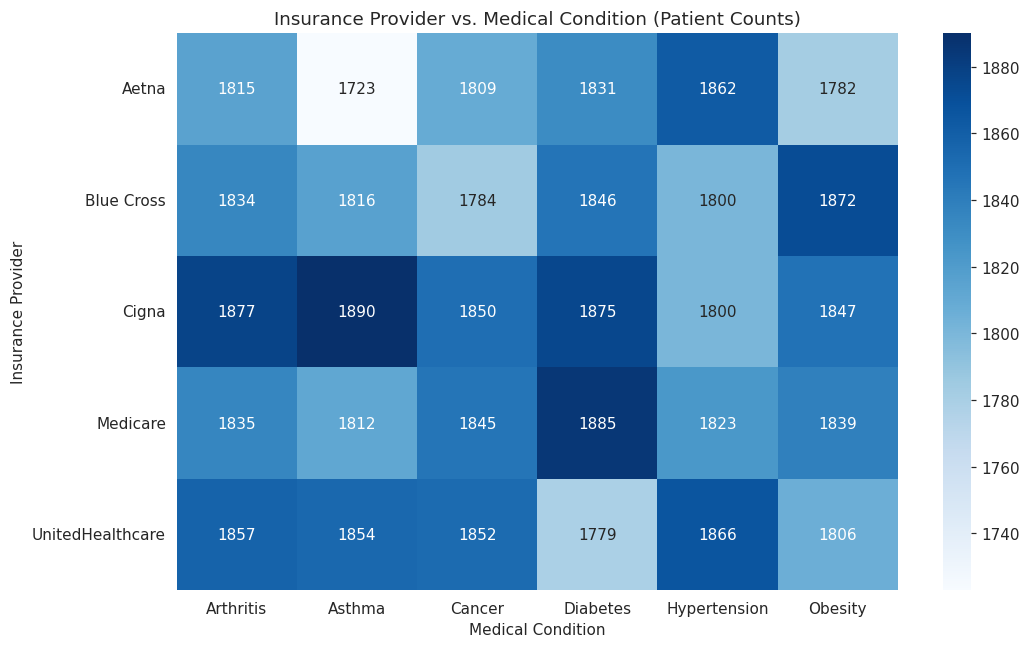

In [10]:
insurance_condition = pd.crosstab(df["Insurance Provider"], df["Medical Condition"])

plt.figure(figsize=(10, 6))
sns.heatmap(insurance_condition, annot=True, fmt="d", cmap="Blues")
plt.title("Insurance Provider vs. Medical Condition (Patient Counts)")
plt.tight_layout()
plt.show()

## 4. Revenue Analysis

Total billed revenue over time — by year, month, and admission type — treating `Billing Amount` as billed revenue.

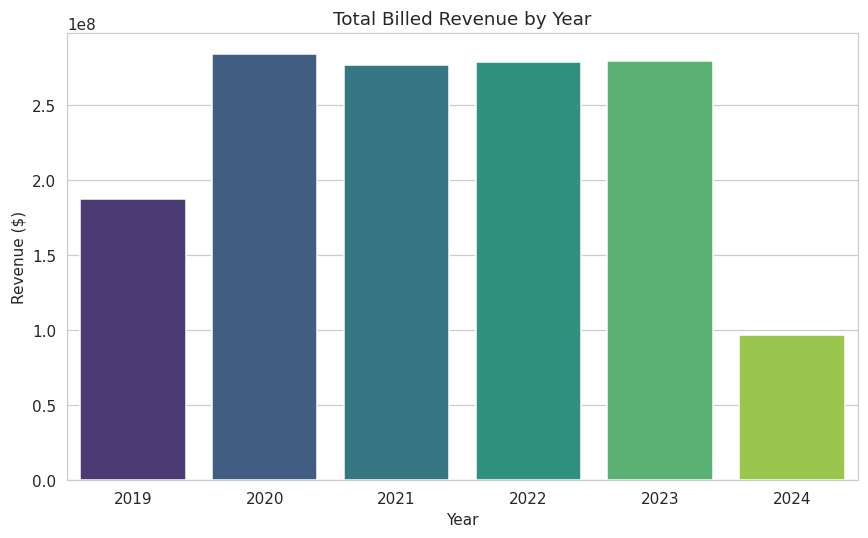

Admission_Year
2019    1.875258e+08
2020    2.839666e+08
2021    2.771949e+08
2022    2.786391e+08
2023    2.796911e+08
2024    9.715746e+07
Name: Billing Amount, dtype: float64

In [11]:
annual_revenue = df.groupby("Admission_Year")["Billing Amount"].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=annual_revenue.index.astype(str), y=annual_revenue.values, hue=annual_revenue.index.astype(str), legend=False, palette="viridis")
plt.title("Total Billed Revenue by Year")
plt.ylabel("Revenue ($)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()
annual_revenue.round(2)

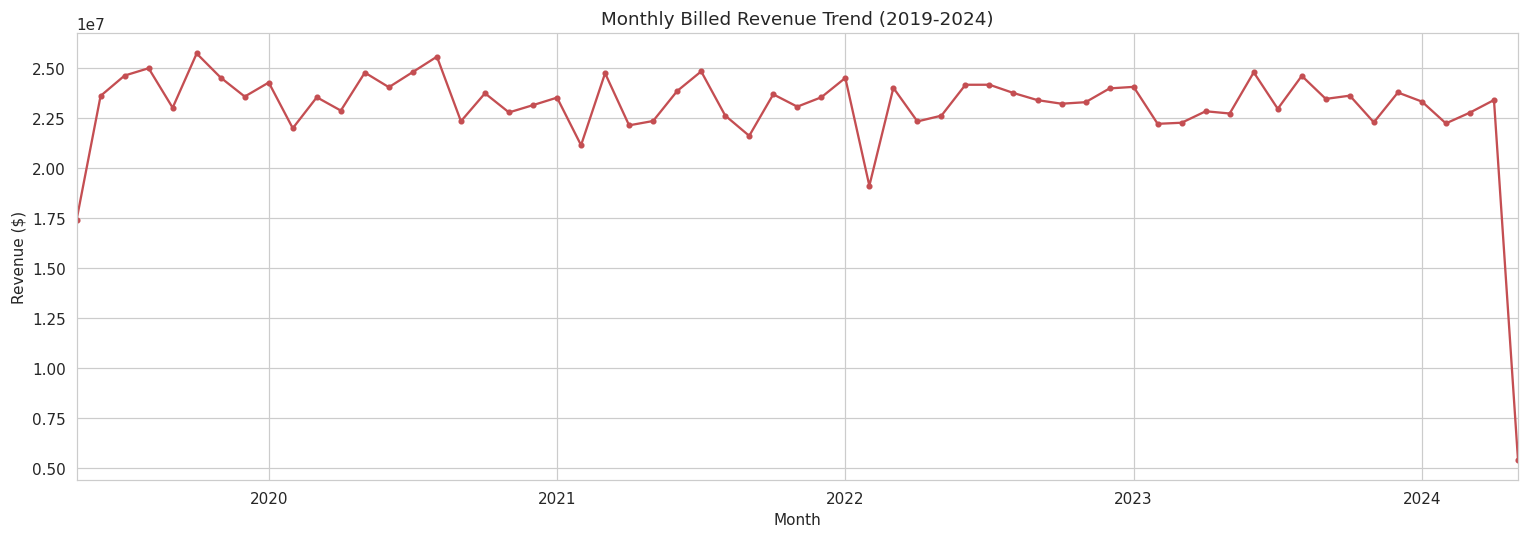

In [12]:
monthly_revenue = df.groupby(df["Date of Admission"].dt.to_period("M"))["Billing Amount"].sum()

plt.figure(figsize=(14, 5))
monthly_revenue.plot(kind="line", marker="o", markersize=3, color="#C44E52")
plt.title("Monthly Billed Revenue Trend (2019-2024)")
plt.ylabel("Revenue ($)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

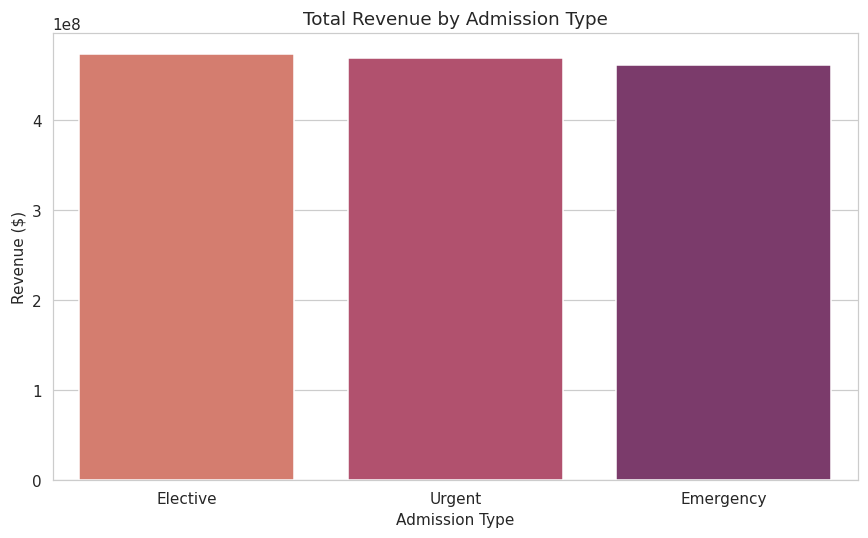

Admission Type
Elective     4.731770e+08
Urgent       4.692774e+08
Emergency    4.617204e+08
Name: Billing Amount, dtype: float64

In [13]:
revenue_by_type = df.groupby("Admission Type")["Billing Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_type.index, y=revenue_by_type.values, hue=revenue_by_type.index, legend=False, palette="flare")
plt.title("Total Revenue by Admission Type")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()
revenue_by_type.round(2)

In [14]:
revenue_per_los_category = df.groupby("LOS_Category")["Billing Amount"].agg(["sum", "mean", "count"]).round(2)
revenue_per_los_category.columns = ["Total_Revenue", "Avg_Revenue", "Patient_Count"]
order_los = ["Short (1-3 days)", "Medium (4-10 days)", "Long (11-20 days)", "Extended (21+ days)"]
revenue_per_los_category.reindex(order_los)

,Total_Revenue,Avg_Revenue,Patient_Count
LOS_Category,,,
Short (1-3 days),1.394404e+08,25510.50,5466
Medium (4-10 days),3.315156e+08,25756.78,12871
Long (11-20 days),4.656698e+08,25454.78,18294
Extended (21+ days),4.675492e+08,25500.36,18335


## 5. Hospital Analysis

The dataset contains a very high number of distinct hospital names (near one-per-few-patients), so analysis focuses on the top hospitals by patient volume and revenue.

Unique hospitals: 39876
Unique doctors: 40341


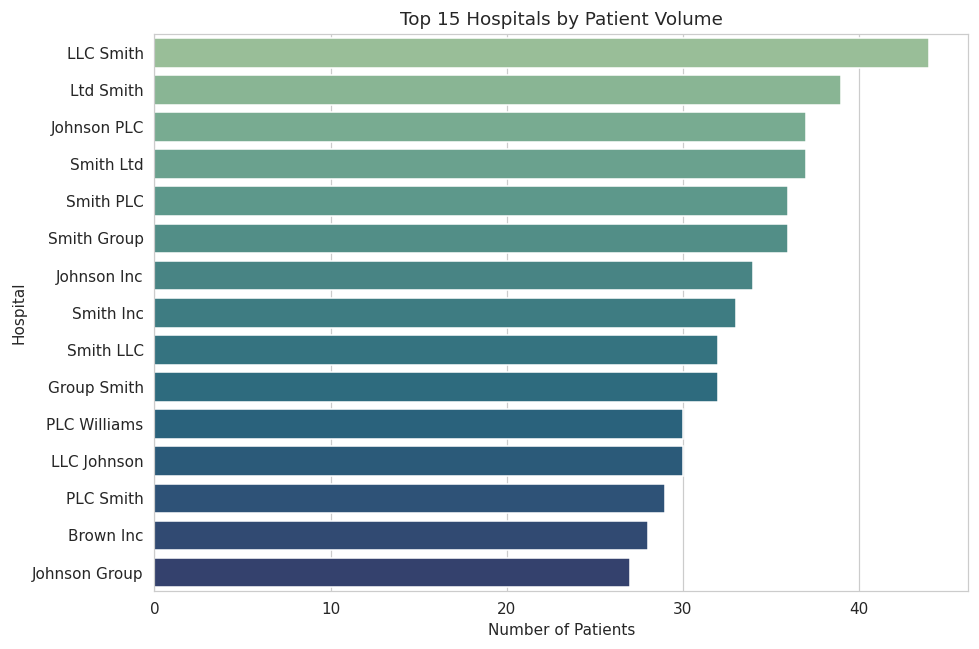

Hospital
LLC Smith        44
Ltd Smith        39
Johnson PLC      37
Smith Ltd        37
Smith PLC        36
Smith Group      36
Johnson Inc      34
Smith Inc        33
Smith LLC        32
Group Smith      32
PLC Williams     30
LLC Johnson      30
PLC Smith        29
Brown Inc        28
Johnson Group    27
Name: count, dtype: int64

In [15]:
print("Unique hospitals:", df["Hospital"].nunique())
print("Unique doctors:", df["Doctor"].nunique())

top_hospitals_volume = df["Hospital"].value_counts().head(15)

plt.figure(figsize=(9, 6))
sns.barplot(y=top_hospitals_volume.index, x=top_hospitals_volume.values, hue=top_hospitals_volume.index, legend=False, palette="crest")
plt.title("Top 15 Hospitals by Patient Volume")
plt.xlabel("Number of Patients")
plt.tight_layout()
plt.show()
top_hospitals_volume

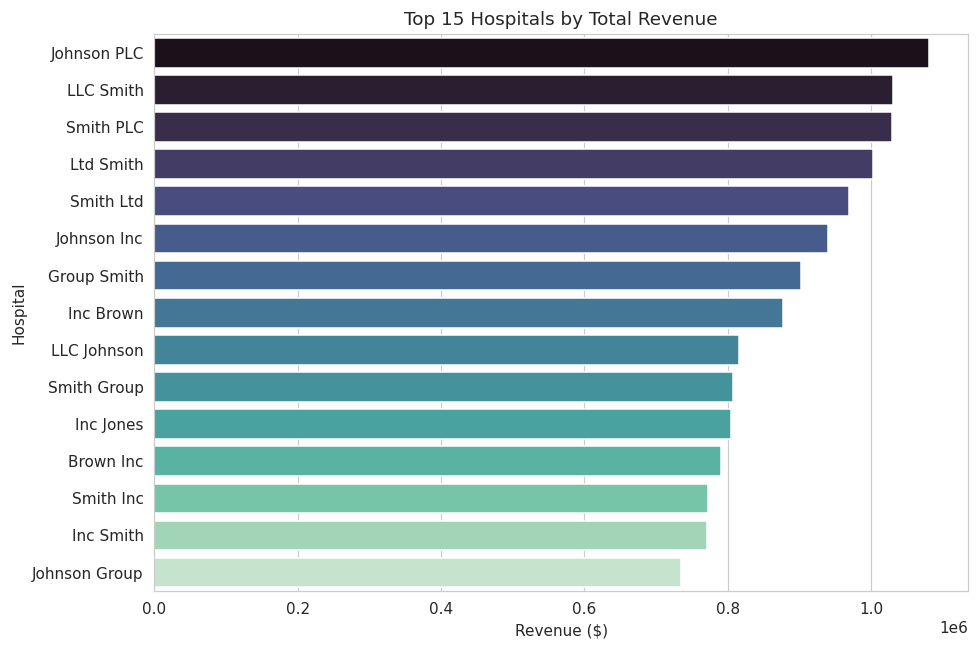

Hospital
Johnson PLC      1081477.31
LLC Smith        1030189.87
Smith PLC        1029424.45
Ltd Smith        1003365.53
Smith Ltd         970035.87
Johnson Inc       939551.82
Group Smith       902975.79
Inc Brown         877961.31
LLC Johnson       816438.35
Smith Group       806904.57
Inc Jones         804936.44
Brown Inc         790322.57
Smith Inc         772256.50
Inc Smith         770747.93
Johnson Group     734430.55
Name: Billing Amount, dtype: float64

In [16]:
top_hospitals_revenue = df.groupby("Hospital")["Billing Amount"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(y=top_hospitals_revenue.index, x=top_hospitals_revenue.values, hue=top_hospitals_revenue.index, legend=False, palette="mako")
plt.title("Top 15 Hospitals by Total Revenue")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()
top_hospitals_revenue.round(2)

In [17]:
hospital_summary = df.groupby("Hospital").agg(
    Patient_Count=("Name", "count"),
    Avg_Billing=("Billing Amount", "mean"),
    Avg_LOS=("Length_of_Stay", "mean")
).round(2)

hospital_summary = hospital_summary[hospital_summary["Patient_Count"] >= 5].sort_values("Avg_Billing", ascending=False)
print(f"Hospitals with 5+ patients: {len(hospital_summary)}")
hospital_summary.head(15)

Hospitals with 5+ patients: 794


,Patient_Count,Avg_Billing,Avg_LOS
Hospital,,,
Ltd Alexander,5,43405.60,20.60
Inc Torres,5,42007.99,12.20
Valdez LLC,5,41384.46,11.80
Inc Perkins,5,41093.19,22.20
Inc Williamson,5,39531.80,17.00
Group Martinez,10,39189.83,10.30
Shaw LLC,8,39113.20,12.62
Parker LLC,5,38942.04,16.00
Ltd Carter,6,38740.48,13.50


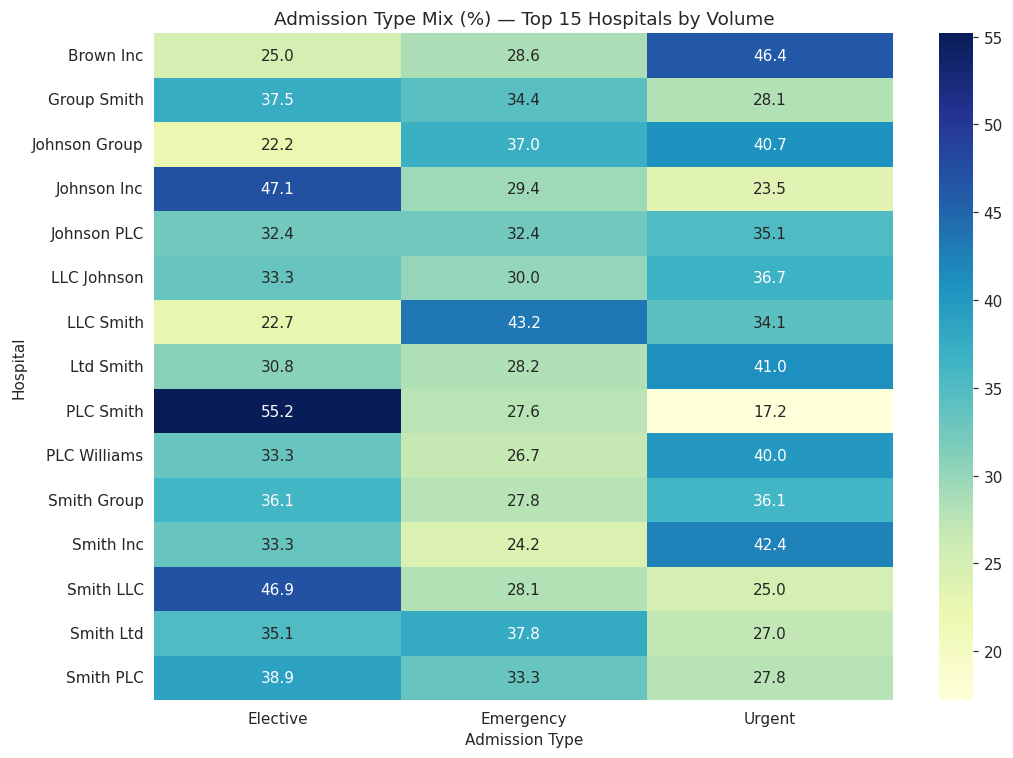

In [18]:
hospital_admission_mix = pd.crosstab(
    df[df["Hospital"].isin(top_hospitals_volume.index)]["Hospital"],
    df["Admission Type"],
    normalize="index"
).round(3) * 100

plt.figure(figsize=(10, 7))
sns.heatmap(hospital_admission_mix, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Admission Type Mix (%) — Top 15 Hospitals by Volume")
plt.tight_layout()
plt.show()

## Summary

- **Billing**: Billing amounts range broadly with no single dominant driver; correlation with length of stay is negligible, suggesting billing is largely condition/procedure-driven rather than duration-driven.
- **Insurance**: Patient volume and average billing are fairly evenly spread across the five insurance providers.
- **Revenue**: Total billed revenue tracks admission volume year over year, with 2024 showing a partial year (data ends May 2024).
- **Hospitals**: With ~39,900 distinct hospital names across 55,500 records, most hospitals see only a handful of patients — the top-volume hospitals were isolated for meaningful comparison.
